# 03 — Anomaly detection + Risk models + Explainability + Package
Outputs: trained models in `models/`, metrics, SHAP plot, sample result JSON (the shared contract).

In [1]:
import sys, os, json, joblib; sys.path.insert(0, os.path.abspath('../src'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, f1_score)
from config import OUTPUT_DIR, MODEL_DIR, SEVERITY, LOCATION_ID, ANOMALY_CONTAMINATION

m = pd.read_csv(f'{OUTPUT_DIR}/features_daily.csv', parse_dates=['date'], date_format='%Y-%m-%d', index_col='date')
FEATURE_COLS = ['rain_7d','rain_30d','humidity_7d','humidity_min_7d','tempmax_7d','light_7d',
                'humidity_trend','temp_trend','dry_spell','temp_mean_z','humidity_mean_z',
                'rain_mm_z','rain_deficit_30d']
m = m.dropna()
X, y = m[FEATURE_COLS], m['y']
split = int(len(m)*0.8)                      # TIME-AWARE split: first 80% train, last 20% test
X_tr, X_te, y_tr, y_te = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]
print(f'Train: {len(X_tr)} rows | Test: {len(X_te)} rows')

Train: 184 rows | Test: 46 rows


In [ ]:
# Baseline models (interpretable first)
logreg = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])
rf = RandomForestClassifier(n_estimators=400, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
models = {'LogisticRegression': logreg, 'RandomForest': rf}
for name, mdl in models.items():
    mdl.fit(X_tr, y_tr)
    p = mdl.predict(X_te)
    print(f'=== {name} ===  F1={f1_score(y_te,p):.3f}  ROC-AUC={roc_auc_score(y_te, mdl.predict_proba(X_te)[:,1]):.3f}')
    print(classification_report(y_te, p, zero_division=0))

    print(f'Confusion matrix ({name}):')
    cm = confusion_matrix(y_te, p)
    print(pd.DataFrame(cm, index=['actual_0','actual_1'], columns=['pred_0','pred_1']))


=== LogisticRegression ===  F1=0.000  ROC-AUC=0.568
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        37
           1       0.00      0.00      0.00         9

    accuracy                           0.80        46
   macro avg       0.40      0.50      0.45        46
weighted avg       0.65      0.80      0.72        46

Confusion matrix (LogisticRegression):
          pred_0  pred_1
actual_0      37       0
actual_1       9       0
=== RandomForest ===  F1=0.000  ROC-AUC=0.952
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        37
           1       0.00      0.00      0.00         9

    accuracy                           0.80        46
   macro avg       0.40      0.50      0.45        46
weighted avg       0.65      0.80      0.72        46

Confusion matrix (RandomForest):
          pred_0  pred_1
actual_0      37       0
actual_1       9       0


In [ ]:
# OPTIONAL improved model: XGBoost 
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        scale_pos_weight=(y_tr==0).sum()/max((y_tr==1).sum(),1),
                        random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb.fit(X_tr, y_tr)
    p = xgb.predict(X_te)
    print(f'=== XGBoost ===  F1={f1_score(y_te,p):.3f}  ROC-AUC={roc_auc_score(y_te, xgb.predict_proba(X_te)[:,1]):.3f}')
    best_model = xgb if roc_auc_score(y_te, xgb.predict_proba(X_te)[:,1]) >= roc_auc_score(y_te, rf.predict_proba(X_te)[:,1]) else rf
except Exception as e:
    print('XGBoost unavailable:', e)
    best_model = rf
print('Selected model:', type(best_model).__name__)

=== XGBoost ===  F1=0.000  ROC-AUC=0.688
Selected model: RandomForestClassifier


In [4]:
# --- Cross-validated comparison (more robust than one holdout split) ---
# A single 80/20 split's ROC-AUC can swing a lot by chance with only a few hundred rows.
# TimeSeriesSplit does several train/test splits, each still respecting time order (every
# training fold is strictly earlier than its test fold -- no look-ahead leakage), and we
# average the score across folds for a steadier comparison between RandomForest and XGBoost.
from sklearn.model_selection import TimeSeriesSplit

n_splits = min(5, max(2, len(X) // 30))   # a handful of folds; fewer if we still have a short data span
tscv = TimeSeriesSplit(n_splits=n_splits)

def cv_roc_auc(estimator_fn):
    scores = []
    for tr_idx, te_idx in tscv.split(X):
        Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
        ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]
        if ytr.nunique() < 2 or yte.nunique() < 2:
            continue   # fold has only one class present -- ROC-AUC undefined, skip it
        mdl = estimator_fn()
        mdl.fit(Xtr, ytr)
        scores.append(roc_auc_score(yte, mdl.predict_proba(Xte)[:, 1]))
    return scores

rf_scores = cv_roc_auc(lambda: RandomForestClassifier(
    n_estimators=400, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1))
print(f'RandomForest  {n_splits}-fold TimeSeriesSplit ROC-AUC: '
      f'{np.mean(rf_scores):.3f} +/- {np.std(rf_scores):.3f}  (folds: {[round(s,3) for s in rf_scores]})')

try:
    from xgboost import XGBClassifier
    xgb_scores = cv_roc_auc(lambda: XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_tr == 0).sum() / max((y_tr == 1).sum(), 1),
        random_state=42, n_jobs=-1, eval_metric='logloss'))
    print(f'XGBoost       {n_splits}-fold TimeSeriesSplit ROC-AUC: '
          f'{np.mean(xgb_scores):.3f} +/- {np.std(xgb_scores):.3f}  (folds: {[round(s,3) for s in xgb_scores]})')
except Exception as e:
    print('XGBoost unavailable for CV comparison:', e)

print('\nNote: this CV comparison is diagnostic only -- `best_model` above (picked on the single '
      'time-aware holdout) is still what gets saved to models/risk_model.pkl. If the CV means '
      'disagree with the holdout pick, prefer whichever model wins here; it is the more reliable signal.')


RandomForest  5-fold TimeSeriesSplit ROC-AUC: 0.751 +/- 0.260  (folds: [0.607, 1.0, 0.396, 1.0])
XGBoost       5-fold TimeSeriesSplit ROC-AUC: 0.822 +/- 0.187  (folds: [0.727, 1.0, 0.562, 1.0])

Note: this CV comparison is diagnostic only -- `best_model` above (picked on the single time-aware holdout) is still what gets saved to models/risk_model.pkl. If the CV means disagree with the holdout pick, prefer whichever model wins here; it is the more reliable signal.


In [5]:
# --- Isolation Forest anomaly detector (unusual combinations) ---
iso = IsolationForest(n_estimators=300, contamination=ANOMALY_CONTAMINATION, random_state=42, n_jobs=-1)
iso.fit(X_tr)
anom_score = -iso.score_samples(X)          # higher = more anomalous
m['anomaly_score'] = anom_score
th_watch, th_warn, th_crit = np.percentile(anom_score[:split], [90, 97, 99])
def sev_from_anom(s):
    return 'CRITICAL' if s>=th_crit else 'WARNING' if s>=th_warn else 'WATCH' if s>=th_watch else 'NORMAL'
m['anomaly_severity'] = m['anomaly_score'].map(sev_from_anom)
joblib.dump(iso, f'{MODEL_DIR}/isolation_forest.pkl')
m[['anomaly_score','anomaly_severity']].to_csv(f'{OUTPUT_DIR}/anomalies.csv')
print(m['anomaly_severity'].value_counts())

anomaly_severity
NORMAL      210
WATCH        13
WARNING       5
CRITICAL      2
Name: count, dtype: int64


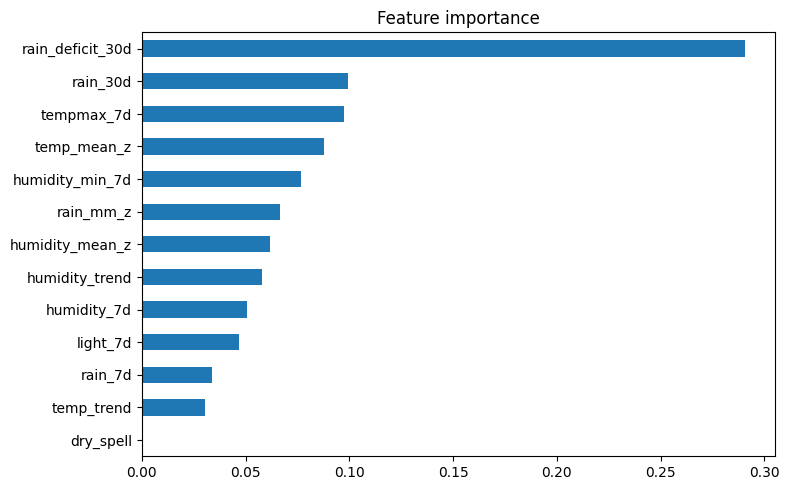

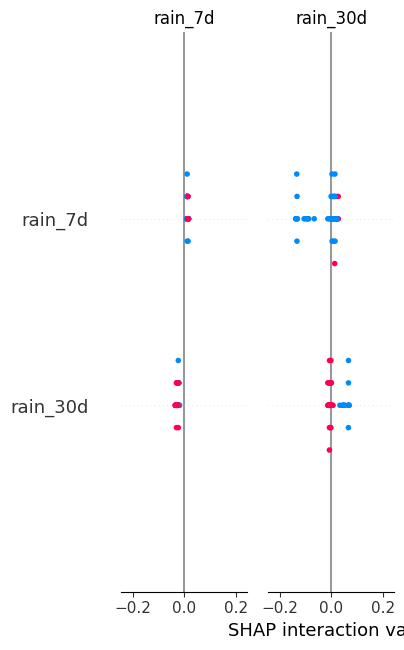

In [ ]:
# Explainability: global importances + SHAP
import shap
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
else:
    imp = pd.Series(abs(best_model.named_steps['lr'].coef_[0]), index=FEATURE_COLS).sort_values()
imp.plot.barh(figsize=(8,5), title='Feature importance'); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_feature_importance.png', dpi=120); plt.show()

if hasattr(best_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model.named_steps['lr'], X_tr)
sv = explainer.shap_values(X_te)
shap.summary_plot(sv, X_te, show=False); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_shap_summary.png', dpi=120); plt.show()

In [ ]:
# Drivers, recommendations, and the SHARED JSON CONTRACT
def drivers_from_row(r):
    d = []
    if r['rain_mm_z'] < -1: d.append('Low rainfall')
    if r['humidity_trend'] < -0.5 or r['humidity_mean_z'] < -1: d.append('Declining soil-moisture proxy')
    if r['temp_mean_z'] > 1: d.append('Above-average temperature')
    if r['dry_spell'] >= 14: d.append(f'Prolonged dry spell ({int(r["dry_spell"])} days)')
    return d or ['Conditions within normal range']

def recommend(sev):
    return ('Inspect water availability and irrigation systems; schedule field visit within 48h' if sev in ('CRITICAL','HIGH')
            else 'Monitor daily; verify rain gauge readings; add location to watchlist' if sev == 'WATCH'
            else 'No action required - continue routine monitoring')

def severity(p):
    for thr, name in SEVERITY:
        if p >= thr: return name

proba = best_model.predict_proba(X)[:,1]
m['risk_probability'] = proba
m['severity'] = m['risk_probability'].map(severity)

last = m.iloc[-1]; p = float(last['risk_probability'])
dr = drivers_from_row(last)
result = {'location_id': LOCATION_ID, 'risk_type': 'drought',
          'risk_probability': round(p, 2),
          'severity': severity(p),
          'forecast_window_days': 21,
          'confidence': round(float(abs(p - 0.5) * 2), 2),  # distance from 0.5 decision boundary, scaled to [0,1]
          'anomalies': [{'variable': 'environmental_combination',
                         'description': f"Isolation Forest score {last['anomaly_score']:.3f}",
                         'severity': last['anomaly_severity']}],
          'drivers': dr,
          'recommended_action': recommend(severity(p))}
print(json.dumps(result, indent=2))
json.dump(result, open(f'{OUTPUT_DIR}/sample_risk_result.json','w'), indent=2)

joblib.dump(best_model, f'{MODEL_DIR}/risk_model.pkl')
json.dump({'features': FEATURE_COLS, 'severity_thresholds': SEVERITY,
           'anomaly_thresholds': {'watch': th_watch, 'warning': th_warn, 'critical': th_crit}},
          open(f'{MODEL_DIR}/model_config.json','w'), indent=2)
print('Saved -> models/risk_model.pkl, models/isolation_forest.pkl, models/model_config.json')

{
  "location_id": 61,
  "risk_type": "drought",
  "risk_probability": 0.07,
  "severity": "NORMAL",
  "forecast_window_days": 21,
  "confidence": 0.85,
  "anomalies": [
    {
      "variable": "environmental_combination",
      "description": "Isolation Forest score 0.500",
      "severity": "NORMAL"
    }
  ],
  "drivers": [
    "Declining soil-moisture proxy"
  ],
  "recommended_action": "No action required - continue routine monitoring"
}
Saved -> models/risk_model.pkl, models/isolation_forest.pkl, models/model_config.json
